# GNN Routing - Graph Convolutional Network for Traffic-Aware Routing
### PyTorch Geometric: https://pytorch-geometric.readthedocs.io
### Data prepared by: data_prep.ipynb

**Overview:**
Trains a Graph Convolutional Network (GCN) on the road graph and congestion time series produced by `data_prep.ipynb`. The GCN learns to predict a congestion score for each road segment (edge) given the current traffic state at neighboring zones (nodes). These predicted scores are used as edge weights in Dijkstra's algorithm to recommend the least-congested route between any two zones.

**Why GCN:**
A GCN propagates information across the graph — the predicted congestion on one road segment is informed by traffic conditions on neighboring segments. This captures the spatial dependency structure of traffic described in the literature: congestion at one node influences adjacent nodes.

**Baseline comparison:**
GNN-predicted routing is compared against uniform-weight Dijkstra (treats all roads as equally congested) to demonstrate the value of learned congestion prediction.

---
## Cell 1 - Environment Setup

In [50]:
# import dependencies
import sys
import os
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import subprocess
import numpy as np
import networkx as nx
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from IPython.display import display as ipy_display, Image as IPyImage

# checks that dependencies are available
print(f"Python           : {sys.version}")
print(f"PyTorch          : {torch.__version__}")
print(f"CUDA             : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    subprocess.run(['bash', '-c', 'module load cuda/11.8.0'], shell=False)

import torch_geometric
print(f"PyG              : {torch_geometric.__version__}")

# File paths
BASE_DIR    = os.path.expanduser('~/AdvAI_Final')
DATA_PATH   = os.path.join(BASE_DIR, 'routing', 'data_prep_output.pt')
OUTPUT_DIR  = os.path.join(BASE_DIR, 'routing', 'predictions')
MODELS_DIR  = os.path.join(BASE_DIR, 'detection', 'models')
WEBSITE_DIR = os.path.join(BASE_DIR, 'website', 'results')
GNN_CKPT    = os.path.join(MODELS_DIR, 'gnn_routing.pt')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(WEBSITE_DIR, exist_ok=True)

# Training hyperparameters
HIDDEN_DIM   = 128
NUM_LAYERS   = 4
GAT_HEADS    = 4
EPOCHS       = 2500
LR           = 0.001
WINDOW_SIZE  = 10    # number of past timesteps the model sees to predict next timestep
                     # mimics real-time routing — only use recent congestion history

print(f"\nBase         : {BASE_DIR}")
print(f"Data path    : {DATA_PATH}")
print(f"GNN checkpoint: {GNN_CKPT}")
print(f"Device       : {device}")
print(f"\nHyperparameters:")
print(f"  Hidden dim  : {HIDDEN_DIM}")
print(f"  GAT layers  : {NUM_LAYERS}")
print(f"  Heads       : {GAT_HEADS}")
print(f"  Epochs      : {EPOCHS}")
print(f"  Window size : {WINDOW_SIZE} timesteps")

Python           : 3.11.15 (main, Mar 11 2026, 17:20:07) [GCC 14.3.0]
PyTorch          : 2.7.1+cu118
CUDA             : True
GPU              : Tesla V100S-PCIE-32GB
PyG              : 2.7.0

Base         : /users/PGS0295/atrautzs/AdvAI_Final
Data path    : /users/PGS0295/atrautzs/AdvAI_Final/routing/data_prep_output.pt
GNN checkpoint: /users/PGS0295/atrautzs/AdvAI_Final/detection/models/gnn_routing.pt
Device       : cuda

Hyperparameters:
  Hidden dim  : 128
  GAT layers  : 4
  Heads       : 4
  Epochs      : 2500
  Window size : 10 timesteps


---
## Cell 2 - Load Dataset

Loads `data_prep_output.pt` and verifies the interface contract — shapes and dtypes must match what the GCN expects.

In [51]:
if not os.path.exists(DATA_PATH):
    print(f"Dataset not found: {DATA_PATH}")
    print("Run data_prep.ipynb first to generate this file.")
else:
    data_dict = torch.load(DATA_PATH, map_location=device)

    edge_index    = data_dict['edge_index'].to(device)
    node_coords   = data_dict['node_coords'].to(device)
    congestion    = data_dict['congestion'].to(device)     # [num_nodes, num_timesteps]
    num_nodes     = data_dict['num_nodes']
    num_timesteps = data_dict['num_timesteps']
    sequence_ids  = data_dict['sequence_ids']
    seq_node_map  = data_dict['seq_node_map']

    print("Dataset loaded successfully.")
    print()
    print(f"  edge_index    : {edge_index.shape}  dtype={edge_index.dtype}")
    print(f"  node_coords   : {node_coords.shape}  dtype={node_coords.dtype}")
    print(f"  congestion    : {congestion.shape}  dtype={congestion.dtype}")
    print(f"  num_nodes     : {num_nodes}")
    print(f"  num_timesteps : {num_timesteps}")
    print(f"  sequences     : {sequence_ids}")
    print()
    print(f"  Congestion range : [{congestion.min():.4f}, {congestion.max():.4f}]")
    print(f"  Mean congestion  : {congestion.mean():.4f}")

    # Build sliding window training pairs
    # Instead of predicting the mean of held-out timesteps from all training timesteps,
    # we slide a window of size WINDOW_SIZE across the full time series.
    # Each window gives: x = congestion[:, t:t+WINDOW_SIZE], y = congestion[:, t+WINDOW_SIZE]
    # This forces the model to predict the NEXT timestep from recent history —
    # directly mimicking real-time routing where only recent congestion is available.
    windows_x = []  # list of [num_nodes, WINDOW_SIZE] tensors
    windows_y = []  # list of [num_nodes] tensors

    for t in range(num_timesteps - WINDOW_SIZE):
        x = congestion[:, t : t + WINDOW_SIZE]          # [num_nodes, WINDOW_SIZE]
        y = congestion[:, t + WINDOW_SIZE]               # [num_nodes]
        windows_x.append(x)
        windows_y.append(y)

    windows_x = torch.stack(windows_x)  # [num_windows, num_nodes, WINDOW_SIZE]
    windows_y = torch.stack(windows_y)  # [num_windows, num_nodes]

    # Split windows into train and val
    split_w    = int(len(windows_x) * 0.8)
    train_x    = windows_x[:split_w]    # [train_windows, num_nodes, WINDOW_SIZE]
    train_y    = windows_y[:split_w]    # [train_windows, num_nodes]
    val_x      = windows_x[split_w:]
    val_y      = windows_y[split_w:]

    print(f"  Window size      : {WINDOW_SIZE} timesteps")
    print(f"  Total windows    : {len(windows_x)}")
    print(f"  Train windows    : {len(train_x)}")
    print(f"  Val windows      : {len(val_x)}")
    print()
    print(f"  Model input shape per forward pass: [{num_nodes}, {WINDOW_SIZE}]")
    print(f"  Model output shape per forward pass: [{num_nodes}]")

Dataset loaded successfully.

  edge_index    : torch.Size([2, 4780])  dtype=torch.int64
  node_coords   : torch.Size([1260, 2])  dtype=torch.float32
  congestion    : torch.Size([1260, 100])  dtype=torch.float32
  num_nodes     : 1260
  num_timesteps : 100
  sequences     : ['uav0000013_00000_v', 'uav0000013_01073_v', 'uav0000013_01392_v', 'uav0000020_00406_v', 'uav0000071_03240_v', 'uav0000072_04488_v', 'uav0000072_05448_v', 'uav0000072_06432_v', 'uav0000076_00720_v', 'uav0000079_00480_v', 'uav0000084_00000_v', 'uav0000086_00000_v', 'uav0000099_02109_v', 'uav0000117_02622_v', 'uav0000124_00944_v', 'uav0000126_00001_v', 'uav0000137_00458_v', 'uav0000138_00000_v', 'uav0000140_01590_v', 'uav0000143_02250_v', 'uav0000145_00000_v', 'uav0000150_02310_v', 'uav0000182_00000_v', 'uav0000218_00001_v', 'uav0000222_03150_v', 'uav0000239_03720_v', 'uav0000239_12336_v', 'uav0000243_00001_v', 'uav0000244_01440_v', 'uav0000248_00001_v', 'uav0000263_03289_v', 'uav0000264_02760_v', 'uav0000266_03598_v

---
## Cell 3 - Define GCN Model

A three-layer Graph Convolutional Network. Each GCNConv layer aggregates features from neighboring nodes, allowing each zone to incorporate the congestion state of adjacent zones. The output is a single congestion score per node — used as edge weight for routing.

**Input features per node:** congestion time series (num_timesteps values)

**Output per node:** predicted congestion score (scalar)

The model is trained to predict the next timestep's congestion from the current state — a one-step forecasting objective that forces it to learn the spatial propagation patterns of congestion across the graph.

In [52]:
from torch_geometric.nn import GATConv

class TrafficGAT(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_layers, heads=4):
        super().__init__()
        self.convs     = nn.ModuleList()
        self.bns       = nn.ModuleList()
        self.residuals = nn.ModuleList()

        # Input projection — projects window of timesteps to hidden dim
        self.input_proj = nn.Linear(in_dim, hidden_dim)

        # Input layer
        self.convs.append(GATConv(hidden_dim, hidden_dim, heads=heads, concat=False, dropout=0.2))
        self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.residuals.append(nn.Identity())

        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_dim, hidden_dim, heads=heads, concat=False, dropout=0.2))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
            self.residuals.append(nn.Identity())

        # Output layer
        self.out_conv = GATConv(hidden_dim, hidden_dim // 2, heads=1, concat=False, dropout=0.1)
        self.out_fc   = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x, edge_index):
        # x: [num_nodes, WINDOW_SIZE]
        x = F.relu(self.input_proj(x))

        for conv, bn, res in zip(self.convs, self.bns, self.residuals):
            x_in = x
            x    = conv(x, edge_index)
            x    = bn(x)
            x    = F.elu(x)
            x    = F.dropout(x, p=0.2, training=self.training)
            x    = x + res(x_in)

        x = self.out_conv(x, edge_index)
        x = F.elu(x)
        x = self.out_fc(x)
        return torch.sigmoid(x).squeeze(-1)  # [num_nodes] in [0, 1]


# Input dim is now WINDOW_SIZE not num_timesteps
in_dim = WINDOW_SIZE
model  = TrafficGAT(in_dim, HIDDEN_DIM, NUM_LAYERS, heads=GAT_HEADS).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"TrafficGAT architecture:")
print(f"  Input dim    : {in_dim} (window of {WINDOW_SIZE} recent timesteps)")
print(f"  Hidden dim   : {HIDDEN_DIM}")
print(f"  GAT layers   : {NUM_LAYERS}")
print(f"  Heads        : {GAT_HEADS}")
print(f"  Output       : predicted congestion at next timestep per node")
print(f"  Total params : {total_params:,}")
print()
print(model)

TrafficGAT architecture:
  Input dim    : 10 (window of 10 recent timesteps)
  Hidden dim   : 128
  GAT layers   : 4
  Heads        : 4
  Output       : predicted congestion at next timestep per node
  Total params : 210,689

TrafficGAT(
  (convs): ModuleList(
    (0-2): 3 x GATConv(128, 128, heads=4)
  )
  (bns): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (residuals): ModuleList(
    (0-2): 3 x Identity()
  )
  (input_proj): Linear(in_features=10, out_features=128, bias=True)
  (out_conv): GATConv(128, 64, heads=1)
  (out_fc): Linear(in_features=64, out_features=1, bias=True)
)


---
## Cell 4A - Train GCN - 200 Epochs (Default)

Trains TrafficGCN to predict each node's congestion at the next timestep given its neighborhood's current state. Loss is MSE between predicted and actual congestion. Training and validation loss are tracked per epoch.

Starting TrafficGAT training — temporal window approach
  Epochs       : 2500
  Window size  : 10 timesteps → predict next timestep
  Train windows: 72
  Val windows  : 18
  Optimizer    : Adam (lr=0.001 → cosine warm restarts → 1e-5)
  Nodes        : 1260
  Edges        : 4780

  Epoch     1/2500   train: 0.025963   val: 0.012782   best: 0.012782   lr: 0.001000
  Epoch   100/2500   train: 0.009404   val: 0.008242   best: 0.008120   lr: 0.000905
  Epoch   200/2500   train: 0.008845   val: 0.007832   best: 0.007818   lr: 0.000658
  Epoch   300/2500   train: 0.008502   val: 0.007687   best: 0.007633   lr: 0.000352
  Epoch   400/2500   train: 0.008350   val: 0.007656   best: 0.007612   lr: 0.000105
  Epoch   500/2500   train: 0.008319   val: 0.007616   best: 0.007584   lr: 0.001000
  Epoch   600/2500   train: 0.008417   val: 0.007710   best: 0.007584   lr: 0.000976
  Epoch   700/2500   train: 0.006175   val: 0.005784   best: 0.005736   lr: 0.000905
  Epoch   800/2500   train: 0.005844   v

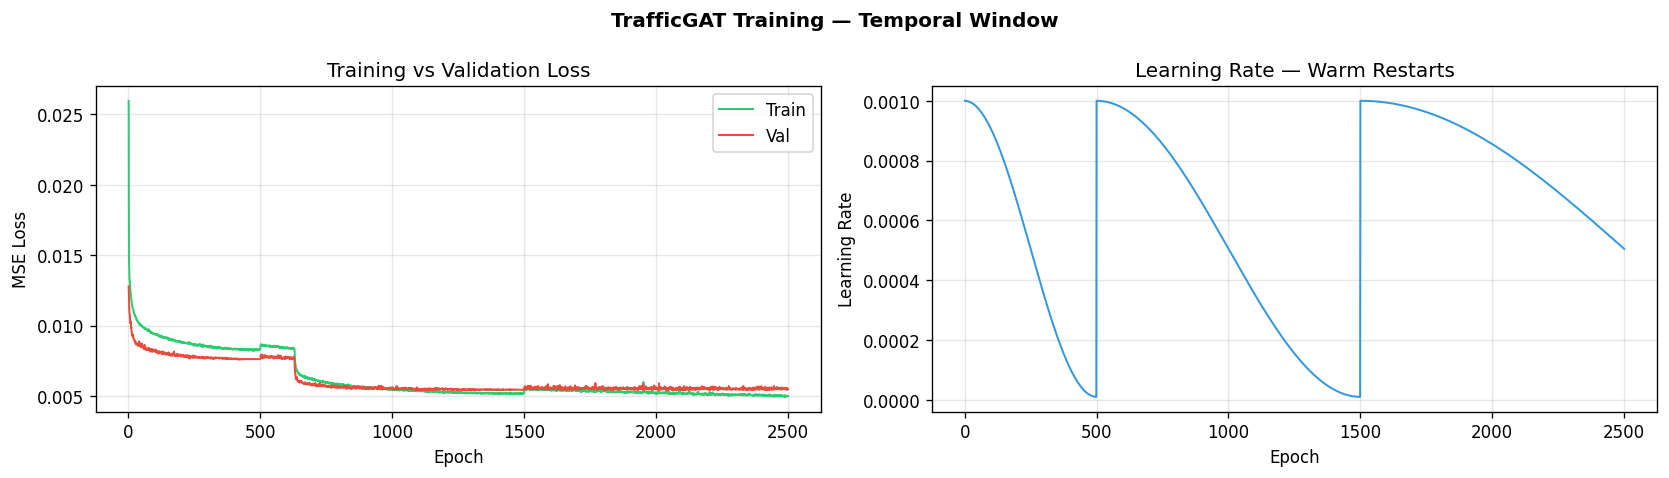

In [53]:
optimizer  = torch.optim.Adam(model.parameters(), lr=LR)
criterion  = nn.MSELoss()
scheduler  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=500, T_mult=2, eta_min=1e-5
)

train_losses = []
val_losses   = []
lr_history   = []
best_loss    = float('inf')

print(f"Starting TrafficGAT training — temporal window approach")
print(f"  Epochs       : {EPOCHS}")
print(f"  Window size  : {WINDOW_SIZE} timesteps → predict next timestep")
print(f"  Train windows: {len(train_x)}")
print(f"  Val windows  : {len(val_x)}")
print(f"  Optimizer    : Adam (lr={LR} → cosine warm restarts → 1e-5)")
print(f"  Nodes        : {num_nodes}")
print(f"  Edges        : {edge_index.shape[1]}")
print()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    # Shuffle window order each epoch
    perm = torch.randperm(len(train_x))

    for idx in perm:
        x_win = train_x[idx]   # [num_nodes, WINDOW_SIZE]
        y_win = train_y[idx]   # [num_nodes]

        optimizer.zero_grad()

        # Noise augmentation
        noise = torch.randn_like(x_win) * 0.05
        pred  = model(x_win + noise, edge_index)
        loss  = criterion(pred, y_win)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()

    avg_train_loss = epoch_loss / len(train_x)
    train_losses.append(avg_train_loss)
    lr_history.append(optimizer.param_groups[0]['lr'])

    # Validation
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for idx in range(len(val_x)):
            pred     = model(val_x[idx], edge_index)
            val_loss += criterion(pred, val_y[idx]).item()
        avg_val_loss = val_loss / len(val_x)
        val_losses.append(avg_val_loss)

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), GNN_CKPT)

    if epoch % 100 == 0 or epoch == 1:
        print(f"  Epoch {epoch:>5}/{EPOCHS}   train: {avg_train_loss:.6f}   val: {avg_val_loss:.6f}   best: {best_loss:.6f}   lr: {optimizer.param_groups[0]['lr']:.6f}")

print()
print(f"Training complete.")
print(f"Best val loss  : {best_loss:.6f}")
print(f"Checkpoint     : {GNN_CKPT}")

# Plot loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('TrafficGAT Training — Temporal Window', fontsize=12, fontweight='bold')

axes[0].plot(range(1, EPOCHS + 1), train_losses, color='#2ecc71', linewidth=1.2, label='Train')
axes[0].plot(range(1, EPOCHS + 1), val_losses,   color='#e74c3c', linewidth=1.2, label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS + 1), lr_history, color='#3498db', linewidth=1.2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate — Warm Restarts')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
loss_path = os.path.join(OUTPUT_DIR, 'gnn_training_loss.png')
plt.savefig(loss_path, dpi=120, bbox_inches='tight')
plt.close()
shutil.copy(loss_path, os.path.join(WEBSITE_DIR, 'gnn_training_loss.png'))
ipy_display(IPyImage(filename=loss_path))

---
## Cell 4B - Train GCN - Custom Epochs

In [25]:
epochs_input  = input("Enter number of epochs for custom run (e.g. 50, 100): ").strip()
EPOCHS_CUSTOM = int(epochs_input)

model_custom  = TrafficGCN(in_dim, HIDDEN_DIM, NUM_LAYERS).to(device)
opt_custom    = torch.optim.Adam(model_custom.parameters(), lr=LR)
losses_custom = []
best_custom   = float('inf')
ckpt_custom   = os.path.join(MODELS_DIR, f'gnn_routing_{EPOCHS_CUSTOM}epoch.pt')

print(f"Starting custom run — {EPOCHS_CUSTOM} epochs")
print()

model_custom.train()
for epoch in range(1, EPOCHS_CUSTOM + 1):
    opt_custom.zero_grad()
    pred = model_custom(graph_data.x, graph_data.edge_index)
    loss = criterion(pred, graph_data.y)
    loss.backward()
    opt_custom.step()
    losses_custom.append(loss.item())
    if loss.item() < best_custom:
        best_custom = loss.item()
        torch.save(model_custom.state_dict(), ckpt_custom)
    if epoch % max(1, EPOCHS_CUSTOM // 5) == 0 or epoch == 1:
        print(f"  Epoch {epoch:>4}/{EPOCHS_CUSTOM}   loss: {loss.item():.6f}")

print()
print(f"Custom training complete. Best loss: {best_custom:.6f}")
print(f"Checkpoint: {ckpt_custom}")

Enter number of epochs for custom run (e.g. 50, 100):  -1


NameError: name 'TrafficGCN' is not defined

---
## Cell 5 - Evaluate - GNN vs Baseline

Loads the best checkpoint and compares two routing strategies across all node pairs:

- **Baseline** — Dijkstra with uniform edge weights (all roads treated equally)
- **GNN** — Dijkstra with GCN-predicted congestion scores as edge weights

The metric is average route congestion: the mean predicted congestion score along the recommended path. Lower is better — a good router avoids high-congestion edges.

GNN predicted congestion scores per node (from last 10 timesteps):
  Node    0: 0.0119
  Node    1: 0.0096
  Node    2: 0.0165
  Node    3: 0.3783
  Node    4: 0.2080
  Node    5: 0.0072
  Node    6: 0.0138
  Node    7: 0.0096
  Node    8: 0.0107
  Node    9: 0.0163
  Node   10: 0.0120
  Node   11: 0.0096
  Node   12: 0.0135
  Node   13: 0.0307
  Node   14: 0.0096
  Node   15: 0.2463
  Node   16: 0.0106
  Node   17: 0.0156
  Node   18: 0.0146
  Node   19: 0.0113
  Node   20: 0.0045
  Node   21: 0.4822
  Node   22: 0.0047
  Node   23: 0.2597
  Node   24: 0.0054
  Node   25: 0.0046
  Node   26: 0.0125
  Node   27: 0.3776
  Node   28: 0.0042
  Node   29: 0.0125
  Node   30: 0.0047
  Node   31: 0.4045
  Node   32: 0.0127
  Node   33: 0.0065
  Node   34: 0.0050
  Node   35: 0.0046
  Node   36: 0.0042
  Node   37: 0.0231
  Node   38: 0.0065
  Node   39: 0.0759
  Node   40: 0.0157
  Node   41: 0.0004
  Node   42: 0.0051
  Node   43: 0.0141
  Node   44: 0.0041
  Node   45: 0.0050
  Node   46: 

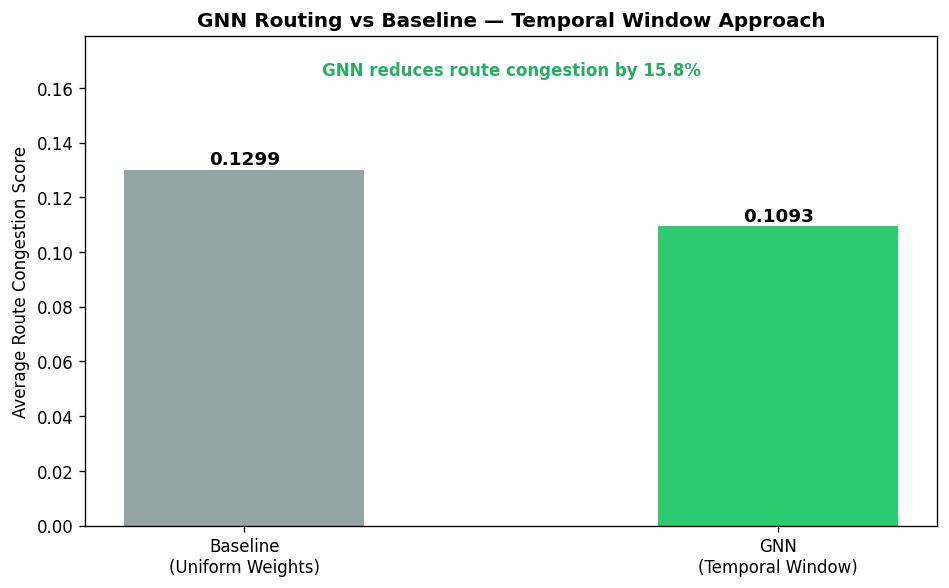

In [54]:
# Load best checkpoint
model.load_state_dict(torch.load(GNN_CKPT, map_location=device))
model.eval()

# At inference time use the last WINDOW_SIZE timesteps as the current window
# This mimics real deployment — you only have access to recent congestion history
with torch.no_grad():
    current_window = congestion[:, -WINDOW_SIZE:]    # [num_nodes, WINDOW_SIZE]
    gnn_scores     = model(current_window, edge_index).cpu().numpy()  # [num_nodes]

print(f"GNN predicted congestion scores per node (from last {WINDOW_SIZE} timesteps):")
for i, s in enumerate(gnn_scores):
    print(f"  Node {i:>4}: {s:.4f}")
print()

# Build NetworkX graphs for routing
G_baseline = nx.DiGraph()
G_gnn      = nx.DiGraph()

src_list = edge_index[0].cpu().tolist()
dst_list = edge_index[1].cpu().tolist()

for s, d in zip(src_list, dst_list):
    G_baseline.add_edge(s, d, weight=1.0)
    gnn_w = float((gnn_scores[s] + gnn_scores[d]) / 2)
    G_gnn.add_edge(s, d, weight=max(gnn_w, 1e-6))

# Evaluate over all valid source-destination pairs
nodes          = list(range(num_nodes))
baseline_congs = []
gnn_congs      = []
pair_results   = []

for src in nodes:
    for dst in nodes:
        if src == dst:
            continue
        try:
            path_base = nx.shortest_path(G_baseline, src, dst, weight='weight')
            path_gnn  = nx.shortest_path(G_gnn,      src, dst, weight='weight')
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            continue

        cong_base = float(np.mean([gnn_scores[n] for n in path_base]))
        cong_gnn  = float(np.mean([gnn_scores[n] for n in path_gnn]))
        baseline_congs.append(cong_base)
        gnn_congs.append(cong_gnn)
        pair_results.append((src, dst, path_base, path_gnn, cong_base, cong_gnn))

avg_base = float(np.mean(baseline_congs)) if baseline_congs else 0
avg_gnn  = float(np.mean(gnn_congs))      if gnn_congs      else 0
improv   = ((avg_base - avg_gnn) / avg_base * 100) if avg_base > 0 else 0

divergent    = [(b, g) for _, _, pb, pg, b, g in pair_results if pb != pg]
div_base_avg = float(np.mean([b for b, g in divergent])) if divergent else 0
div_gnn_avg  = float(np.mean([g for b, g in divergent])) if divergent else 0
div_improv   = ((div_base_avg - div_gnn_avg) / div_base_avg * 100) if div_base_avg > 0 else 0

print("=" * 55)
print(f"{'Strategy':<30} {'Avg Route Congestion':>20}")
print("-" * 55)
print(f"{'Baseline (uniform weights)':<30} {avg_base:>20.4f}")
print(f"{'GNN (learned weights)':<30} {avg_gnn:>20.4f}")
print("-" * 55)
print(f"Overall improvement    : {improv:.1f}%")
print(f"Pairs evaluated        : {len(pair_results)}")
print()
print(f"--- Divergent routes only (GNN chose differently) ---")
print(f"Divergent pairs        : {len(divergent)} / {len(pair_results)}")
if divergent:
    print(f"Baseline avg cong      : {div_base_avg:.4f}")
    print(f"GNN avg cong           : {div_gnn_avg:.4f}")
    print(f"Improvement on these   : {div_improv:.1f}%")
print("=" * 55)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    ['Baseline\n(Uniform Weights)', 'GNN\n(Temporal Window)'],
    [avg_base, avg_gnn],
    color=['#95a5a6', '#2ecc71'],
    width=0.45
)
ax.set_ylabel('Average Route Congestion Score')
ax.set_title('GNN Routing vs Baseline — Temporal Window Approach',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(avg_base, avg_gnn) * 1.3 + 0.01)
for bar, val in zip(bars, [avg_base, avg_gnn]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.text(0.5, 0.92, f'GNN reduces route congestion by {improv:.1f}%',
        transform=ax.transAxes, ha='center', fontsize=10,
        color='#27ae60', fontweight='bold')
plt.tight_layout()
eval_path = os.path.join(OUTPUT_DIR, 'gnn_vs_baseline.png')
plt.savefig(eval_path, dpi=120, bbox_inches='tight')
plt.close()
shutil.copy(eval_path, os.path.join(WEBSITE_DIR, 'gnn_vs_baseline.png'))
ipy_display(IPyImage(filename=eval_path))

---
## Cell 6 - Interactive - Route Recommendation

Select a sequence, then pick source and destination zones within that scene. The GNN predicts congestion scores and Dijkstra finds the optimal route. Both baseline and GNN paths are displayed overlaid on the actual aerial image from that sequence.

In [10]:
import matplotlib.image as mpimg
from matplotlib.lines import Line2D

# Get GNN scores
model.eval()
with torch.no_grad():
    scores = model(graph_data.x, graph_data.edge_index).cpu().numpy()

coords = node_coords.cpu().numpy()  # [num_nodes, 2]

# Step 1 — show available sequences with edge counts and congestion summary
print("Available sequences (only sequences with edges can be routed):")
print()
print(f"{'Seq ID':<12} {'Zones':>6} {'Edges':>6} {'Avg Cong':>10} {'Max Cong':>10}  Nodes")
print("-" * 65)

routable = {}  # seq_id -> local zone indices (0-based within sequence)
for seq_id, local_nodes in seq_node_map.items():
    # Count edges within this sequence
    s_set  = set(local_nodes)
    n_edges = sum(
        1 for s, d in zip(edge_index[0].tolist(), edge_index[1].tolist())
        if s in s_set and d in s_set
    ) // 2  # bidirectional so divide by 2
    if n_edges == 0:
        continue
    seq_scores = scores[local_nodes]
    routable[seq_id] = local_nodes
    print(f"  {str(seq_id):<10} {len(local_nodes):>6} {n_edges:>6} "
          f"{seq_scores.mean():>10.4f} {seq_scores.max():>10.4f}  "
          f"global {local_nodes[0]}–{local_nodes[-1]}")

print()
print(f"{len(routable)} sequences available for routing.")
print()

# Step 2 — pick a sequence
seq_choice = input("Enter sequence ID from the list above: ").strip()
try:
    seq_choice = int(seq_choice)
except ValueError:
    pass

if seq_choice not in routable:
    print(f"Sequence {seq_choice} not found or has no edges.")
else:
    local_nodes  = routable[seq_choice]
    n_local      = len(local_nodes)
    seq_scores   = scores[local_nodes]  # [n_zones]
    seq_coords   = coords[local_nodes]  # [n_zones, 2]

    # Show local zone summary
    print()
    print(f"Sequence {seq_choice} — {n_local} zones:")
    print(f"  {'Local Zone':>11} {'Global Node':>12} {'Congestion':>12}  Level")
    print("  " + "-" * 46)
    for lz, (gn, sc) in enumerate(zip(local_nodes, seq_scores)):
        level = 'HIGH' if sc > 0.6 else 'MEDIUM' if sc > 0.3 else 'LOW'
        print(f"  {lz:>11} {gn:>12} {sc:>12.4f}  {level}")
    print()

    # Step 3 — pick source and destination local zone
    src_local = int(input(f"Enter source zone (0 to {n_local - 1}): ").strip())
    dst_local = int(input(f"Enter destination zone (0 to {n_local - 1}): ").strip())

    src_global = local_nodes[src_local]
    dst_global = local_nodes[dst_local]

    if src_local == dst_local:
        print("Source and destination must be different.")
    else:
        try:
            path_base_g = nx.shortest_path(G_baseline, src_global, dst_global, weight='weight')
            path_gnn_g  = nx.shortest_path(G_gnn,      src_global, dst_global, weight='weight')
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            print(f"No path found between zone {src_local} and zone {dst_local}.")
            path_base_g, path_gnn_g = None, None

        if path_base_g is not None:
            cong_base = float(np.mean([scores[n] for n in path_base_g]))
            cong_gnn  = float(np.mean([scores[n] for n in path_gnn_g]))

            # Convert global paths back to local zone indices for display
            g_to_l    = {g: l for l, g in enumerate(local_nodes)}
            path_base_l = [g_to_l[n] for n in path_base_g]
            path_gnn_l  = [g_to_l[n] for n in path_gnn_g]

            print(f"\nRoute: Zone {src_local} → Zone {dst_local}")
            print(f"  Baseline path : {' → '.join(map(str, path_base_l))}")
            print(f"  Baseline cong : {cong_base:.4f}")
            print(f"  GNN path      : {' → '.join(map(str, path_gnn_l))}")
            print(f"  GNN cong      : {cong_gnn:.4f}")

            # Find a sample image from this sequence
            sample_img = None
            for split in ['train', 'val', 'test']:
                split_dir = os.path.join(
                    os.path.expanduser('~/AdvAI_Final'),
                    'datasets', 'VisDrone', 'images', split
                )
                if os.path.exists(split_dir):
                    for fname in sorted(os.listdir(split_dir)):
                        if fname.startswith(f'{seq_choice:07d}_') or \
                           fname.startswith(f'{seq_choice}_'):
                            sample_img = os.path.join(split_dir, fname)
                            break
                if sample_img:
                    break

            fig, axes = plt.subplots(1, 2, figsize=(22, 9))
            fig.suptitle(
                f'Route Recommendation — Sequence {seq_choice}: '
                f'Zone {src_local} → Zone {dst_local}',
                fontsize=13, fontweight='bold'
            )

            for ax, path_l, path_g, title, path_color, cong_val in [
                (axes[0], path_base_l, path_base_g,
                 f'Baseline (uniform weights)\nAvg Congestion: {cong_base:.4f}',
                 '#e74c3c', cong_base),
                (axes[1], path_gnn_l,  path_gnn_g,
                 f'GNN (learned weights)\nAvg Congestion: {cong_gnn:.4f}',
                 '#2ecc71', cong_gnn)
            ]:
                # Background — aerial image if available, dark canvas otherwise
                if sample_img:
                    img_arr = mpimg.imread(sample_img)
                    ax.imshow(img_arr, alpha=0.6)
                else:
                    ax.set_facecolor('#2c3e50')

                # Draw all sequence edges in grey
                for s, d in zip(edge_index[0].tolist(), edge_index[1].tolist()):
                    if s in set(local_nodes) and d in set(local_nodes):
                        ax.plot([coords[s][0], coords[d][0]],
                                [coords[s][1], coords[d][1]],
                                color='white', linewidth=1.5, alpha=0.4, zorder=1)

                # Draw recommended path in color
                for i in range(len(path_g) - 1):
                    a, b = path_g[i], path_g[i + 1]
                    ax.plot([coords[a][0], coords[b][0]],
                            [coords[a][1], coords[b][1]],
                            color=path_color, linewidth=5, zorder=2, alpha=0.9)

                # Draw all sequence nodes colored by congestion
                for lz, gn in enumerate(local_nodes):
                    sc = scores[gn]
                    c  = '#e74c3c' if sc > 0.6 else '#f39c12' if sc > 0.3 else '#2ecc71'
                    ax.scatter(coords[gn][0], coords[gn][1],
                               s=350, c=c, zorder=3, edgecolors='white', linewidths=2)
                    ax.text(coords[gn][0] + 6, coords[gn][1] - 6,
                            f'Z{lz}\n{sc:.2f}',
                            color='white', fontsize=8, fontweight='bold',
                            bbox=dict(facecolor='#2c3e50', alpha=0.75,
                                      pad=2, edgecolor='none'), zorder=4)

                # Highlight source and destination
                ax.scatter(seq_coords[src_local][0], seq_coords[src_local][1],
                           s=600, c='#3498db', zorder=5, edgecolors='white', linewidths=2.5)
                ax.scatter(seq_coords[dst_local][0], seq_coords[dst_local][1],
                           s=600, c='#9b59b6', zorder=5, edgecolors='white', linewidths=2.5)

                ax.set_title(title, fontsize=11)
                ax.set_xlabel('X (pixels)')
                ax.set_ylabel('Y (pixels)')

            # Legend
            legend = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db',
                       markersize=11, label='Source'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#9b59b6',
                       markersize=11, label='Destination'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71',
                       markersize=11, label='Low congestion (< 0.3)'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#f39c12',
                       markersize=11, label='Medium congestion (0.3–0.6)'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c',
                       markersize=11, label='High congestion (> 0.6)'),
            ]
            axes[1].legend(handles=legend, loc='lower right', fontsize=9)

            plt.tight_layout()
            out_path  = os.path.join(OUTPUT_DIR,  f'route_seq{seq_choice}_z{src_local}_to_z{dst_local}.png')
            site_path = os.path.join(WEBSITE_DIR, f'route_seq{seq_choice}_z{src_local}_to_z{dst_local}.png')
            plt.savefig(out_path, dpi=120, bbox_inches='tight')
            plt.close()
            shutil.copy(out_path, site_path)
            ipy_display(IPyImage(filename=out_path))
            print(f"\nSaved: {out_path}")

Available sequences (only sequences with edges can be routed):

Seq ID        Zones  Edges   Avg Cong   Max Cong  Nodes
-----------------------------------------------------------------
  uav0000013_00000_v     10     29     0.0495     0.0611  global 0–9
  uav0000013_01073_v     10     28     0.1550     0.1783  global 10–19
  uav0000013_01392_v     10     21     0.0886     0.1449  global 20–29
  uav0000020_00406_v     10     27     0.0544     0.0917  global 30–39
  uav0000071_03240_v     10      9     0.0912     0.2151  global 40–49
  uav0000072_04488_v     10     11     0.1603     0.2530  global 50–59
  uav0000072_05448_v     10      9     0.1907     0.4459  global 60–69
  uav0000072_06432_v     10     13     0.2056     0.3611  global 70–79
  uav0000076_00720_v     10      9     0.1056     0.2946  global 80–89
  uav0000079_00480_v     10     12     0.0154     0.0376  global 90–99
  uav0000084_00000_v     10     30     0.2028     0.2738  global 100–109
  uav0000086_00000_v     10     1

Enter sequence ID from the list above:  uav0000366_00001_v 



Sequence uav0000366_00001_v — 10 zones:
   Local Zone  Global Node   Congestion  Level
  ----------------------------------------------
            0          620       0.2436  LOW
            1          621       0.4415  MEDIUM
            2          622       0.2309  LOW
            3          623       0.1700  LOW
            4          624       0.1300  LOW
            5          625       0.4415  MEDIUM
            6          626       0.1418  LOW
            7          627       0.2388  LOW
            8          628       0.2480  LOW
            9          629       0.1009  LOW



Enter source zone (0 to 9):  0
Enter destination zone (0 to 9):  7



Route: Zone 0 → Zone 7
  Baseline path : 0 → 8 → 1 → 2 → 7
  Baseline cong : 0.2805
  GNN path      : 0 → 8 → 1 → 2 → 7
  GNN cong      : 0.2805


ValueError: Unknown format code 'd' for object of type 'str'